In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from pathlib import Path
BASE = Path().resolve().parent
DATA = BASE / "data"
OUTPUTS= BASE / "outputs"

plt.rcParams.update({
    'figure.facecolor': '#0A0F14', 'axes.facecolor': '#0D1B26',
    'axes.edgecolor': '#1E3A4A', 'text.color': '#CDD9E5',
    'axes.labelcolor': '#7A9AAA', 'xtick.color': '#7A9AAA',
    'ytick.color': '#7A9AAA', 'grid.color': '#1E3A4A', 'grid.alpha': 0.5,
})

In [125]:
df = pd.read_csv(f"{DATA}/tickets.csv", parse_dates=['created_at', 'resolved_at'])
df.head(5)

,ticket_id,created_at,resolved_at,priority,category,agent_id,resolution_hours,sla_limit_hours,sla_breach,reopened,csat_score
0,INC-00001,2025-02-27 08:06:00,2025-02-28 06:04:25.367607,P3-Medium,Network,AGT-00003,21.97,24,False,False,5
1,INC-00002,2025-02-25 09:38:00,2025-02-25 15:38:57.869805,P2-High,Software,AGT-00001,6.02,8,False,True,3
2,INC-00003,2025-05-31 10:55:00,2025-06-01 10:05:53.429897,P3-Medium,Software,AGT-00002,23.18,24,False,True,5
3,INC-00004,2025-03-28 07:24:00,2025-03-29 13:35:03.259865,P3-Medium,Hardware,AGT-00002,30.18,24,True,False,3
4,INC-00005,2025-05-18 08:59:00,2025-05-19 01:06:36.382808,P3-Medium,Access Management,AGT-00008,16.13,24,False,False,4


In [126]:
print(f"Shape: {df.shape}")

print("=== DTYPES ===")
print(df.dtypes)

Shape: (5000, 11)
=== DTYPES ===
ticket_id                   object
created_at          datetime64[ns]
resolved_at         datetime64[ns]
priority                    object
category                    object
agent_id                    object
resolution_hours           float64
sla_limit_hours              int64
sla_breach                    bool
reopened                      bool
csat_score                   int64
dtype: object


In [127]:
print("=== NULLS ===")
print(df.isnull().sum())

=== NULLS ===
ticket_id           0
created_at          0
resolved_at         0
priority            0
category            0
agent_id            0
resolution_hours    0
sla_limit_hours     0
sla_breach          0
reopened            0
csat_score          0
dtype: int64


In [128]:
print("=== BASIC STATS ===")
df.describe().round(2)

=== BASIC STATS ===


,created_at,resolved_at,resolution_hours,sla_limit_hours,csat_score
count,5000,5000,5000.00,5000.00,5000.00
mean,2025-04-02 00:52:07.032000,2025-04-02 23:50:29.783735552,22.97,31.57,3.42
min,2025-01-01 02:54:00,2025-01-01 03:24:00,0.50,4.00,1.00
25%,2025-02-14 20:05:30,2025-02-15 20:02:10.078424832,8.27,8.00,2.00
50%,2025-04-02 09:11:00,2025-04-02 22:02:42.229182976,17.50,24.00,4.00
75%,2025-05-19 17:25:30,2025-05-20 19:06:12.892393728,29.28,24.00,4.00
max,2025-06-30 23:38:00,2025-07-03 09:47:10.292877,113.86,72.00,5.00
std,NaN,NaN,20.16,24.17,1.29


In [129]:
df['agent_id'].unique()

array(['AGT-00003', 'AGT-00001', 'AGT-00002', 'AGT-00008', 'AGT-00012',
       'AGT-00004', 'AGT-00006', 'AGT-00007', 'AGT-00014', 'AGT-00005',
       'AGT-00010', 'AGT-00009', 'AGT-00013', 'AGT-00011', 'AGT-00015'],
      dtype=object)

In [130]:
df['category'].unique()

array(['Network', 'Software', 'Hardware', 'Access Management',
       'Email/Comm'], dtype=object)

In [131]:
df['priority'].unique().tolist()

['P3-Medium', 'P2-High', 'P4-Low', 'P1-Critical']

## **Validate Distribution**

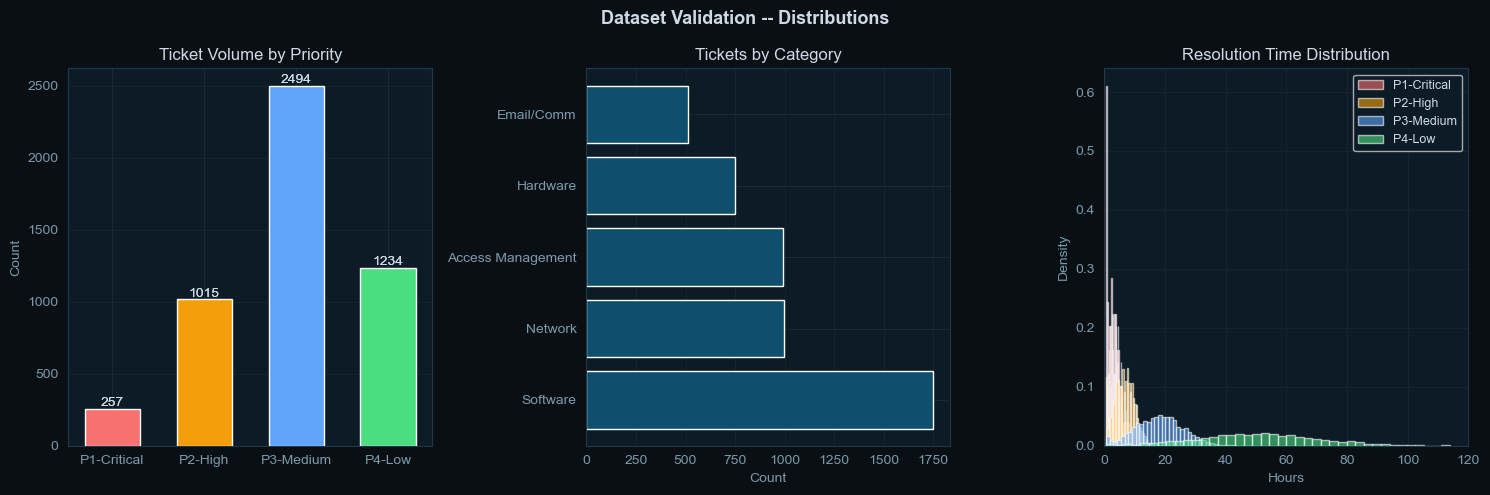

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Dataset Validation -- Distributions", fontsize=13,
             fontweight='bold', color='#CDD9E5')

# Priority distribution
priority_order = ['P1-Critical', 'P2-High', 'P3-Medium', 'P4-Low']
colors_p = ["#F87171","#F59E0B","#60A5FA","#4ADE80"]
counts_p = df['priority'].value_counts().reindex(priority_order)
bars = axes[0].bar(priority_order, counts_p.values, color=colors_p, width=0.6)

for bar, val in zip(bars, counts_p.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 str(val), ha='center', fontsize=10, color='#CDD9E5')

for bar, val in zip(bars, counts_p.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 str(val), ha="center", fontsize=10, color="#CDD9E5")
axes[0].set_title("Ticket Volume by Priority", color="#CDD9E5")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3, axis="y")

# Category Distribution
cat_counts = df['category'].value_counts()
axes[1].barh(cat_counts.index, cat_counts.values, color='#0D4F6C')
axes[1].set_title("Tickets by Category", color="#CDD9E5")
axes[1].set_xlabel("Count")
axes[1].grid(True, alpha=0.3, axis="x")

# Resolution hours of distribution
for priority, color in zip(priority_order, colors_p):
    data = df[df['priority'] == priority]['resolution_hours']
    axes[2].hist(data, bins=40, alpha=0.6, label=priority, color=color, density=True)
axes[2].set_title("Resolution Time Distribution", color="#CDD9E5")
axes[2].set_xlabel("Hours")
axes[2].set_ylabel("Density")
axes[2].legend(fontsize=9)
axes[2].set_xlim(0, 120)
axes[2].grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(f"{OUTPUTS}/charts/01_distributions.png", dpi=150,
            bbox_inches="tight", facecolor="#0A0F14")
plt.show()

## **Feature Engineering**

In [133]:
df['created_at'].dt.day_name()

0       Thursday
1        Tuesday
2       Saturday
3         Friday
4         Sunday
          ...   
4995      Monday
4996    Thursday
4997      Monday
4998    Saturday
4999    Saturday
Name: created_at, Length: 5000, dtype: object

In [134]:
# Day of week and hour - for time pattern recognition
df['day_of_week'] = df['created_at'].dt.day_name()
df['hour_of_day'] = df['created_at'].dt.hour
df["week_number"] = df["created_at"].dt.isocalendar().week.astype(int)
df['month'] = df['created_at'].dt.month_name()
df['month_num'] = df['created_at'].dt.month

# SLA headroom - how many hours over/under time SLA limit
# Negative = resolved with time to spare, Positive = breached
df['sla_headroom_hours'] = df['resolution_hours'] - df['sla_limit_hours']

# SLA breach activity - how badly was SLA breached (% over limits)
df['breach_pct'] = round((df['sla_headroom_hours'] / df['sla_limit_hours']) * 100, 1)

# Ticket age buckets - useful for management summaries
def age_bucket(h):
    if h <= 4: return "< 4h"
    elif h <= 6: return "4-8h"
    elif h <= 8: return "8-24h"
    elif h <= 10: return "1-3 days"
    else: return "> 3 days"

df['age_bucket'] = df['resolution_hours'].apply(age_bucket)

print("New columns added: ")
print(df[['ticket_id', 'sla_headroom_hours', 'breach_pct', 'day_of_week', 'age_bucket']].head(5))

# Save enriched dataset
df.to_csv(f"{DATA}/tickets_enriched.csv", index=False)
print("Saved to data/tickets_enriched.csv")

New columns added: 
   ticket_id  sla_headroom_hours  breach_pct day_of_week age_bucket
0  INC-00001               -2.03        -8.5    Thursday   > 3 days
1  INC-00002               -1.98       -24.8     Tuesday      8-24h
2  INC-00003               -0.82        -3.4    Saturday   > 3 days
3  INC-00004                6.18        25.8      Friday   > 3 days
4  INC-00005               -7.87       -32.8      Sunday   > 3 days
Saved to data/tickets_enriched.csv


In [135]:
df.head()

,ticket_id,created_at,resolved_at,priority,category,agent_id,resolution_hours,sla_limit_hours,sla_breach,reopened,csat_score,day_of_week,hour_of_day,week_number,month,month_num,sla_headroom_hours,breach_pct,age_bucket
0,INC-00001,2025-02-27 08:06:00,2025-02-28 06:04:25.367607,P3-Medium,Network,AGT-00003,21.97,24,False,False,5,Thursday,8,9,February,2,-2.03,-8.5,> 3 days
1,INC-00002,2025-02-25 09:38:00,2025-02-25 15:38:57.869805,P2-High,Software,AGT-00001,6.02,8,False,True,3,Tuesday,9,9,February,2,-1.98,-24.8,8-24h
2,INC-00003,2025-05-31 10:55:00,2025-06-01 10:05:53.429897,P3-Medium,Software,AGT-00002,23.18,24,False,True,5,Saturday,10,22,May,5,-0.82,-3.4,> 3 days
3,INC-00004,2025-03-28 07:24:00,2025-03-29 13:35:03.259865,P3-Medium,Hardware,AGT-00002,30.18,24,True,False,3,Friday,7,13,March,3,6.18,25.8,> 3 days
4,INC-00005,2025-05-18 08:59:00,2025-05-19 01:06:36.382808,P3-Medium,Access Management,AGT-00008,16.13,24,False,False,4,Sunday,8,20,May,5,-7.87,-32.8,> 3 days


## **SLA Compliance**

In [136]:
""" Overall complaince numbers """

total = len(df)
breached = df['sla_breach'].sum()
complaint = total - breached
compliance_rate = (complaint / total) * 100

print("=== SLA COMPLAINCE SUMMARY ===")
print(f"Total Tickets: {total:,}")
print(f"Complaint: {complaint:,} ({compliance_rate:.1f}%)")
print(f"Breach: {breached:,} ({100-compliance_rate:.1f}%)")
print(f"\nTarget SLA rate: 90.0%")
print(f"Current SLA rate: {compliance_rate:.1f}%")
gap = 90.0 - compliance_rate
print(f"Gap to target: {gap:.1f} percentage points")

=== SLA COMPLAINCE SUMMARY ===
Total Tickets: 5,000
Complaint: 3,840 (76.8%)
Breach: 1,160 (23.2%)

Target SLA rate: 90.0%
Current SLA rate: 76.8%
Gap to target: 13.2 percentage points


In [137]:
# By priority
print("=== SLA COMPLAINCE BY PRIORITY ===")
sla_by_priority = df.groupby('priority').agg(
    total=("ticket_id", "count"),
    breached=("sla_breach", "sum"),
).reset_index()

sla_by_priority['compliance_rate'] = (
    (sla_by_priority['total'] - sla_by_priority['breached'])
    / sla_by_priority['total'] * 100
).round(1)

sla_by_priority['breach_rate'] = (
    sla_by_priority['breached'] / sla_by_priority['total'] * 100
).round(1)

print(sla_by_priority.sort_values("breach_rate", ascending=False).to_string(index=False))

=== SLA COMPLAINCE BY PRIORITY ===
   priority  total  breached  compliance_rate  breach_rate
    P2-High   1015       347             65.8         34.2
P1-Critical    257        78             69.6         30.4
  P3-Medium   2494       555             77.7         22.3
     P4-Low   1234       180             85.4         14.6


## **SLA Compliance Chart**

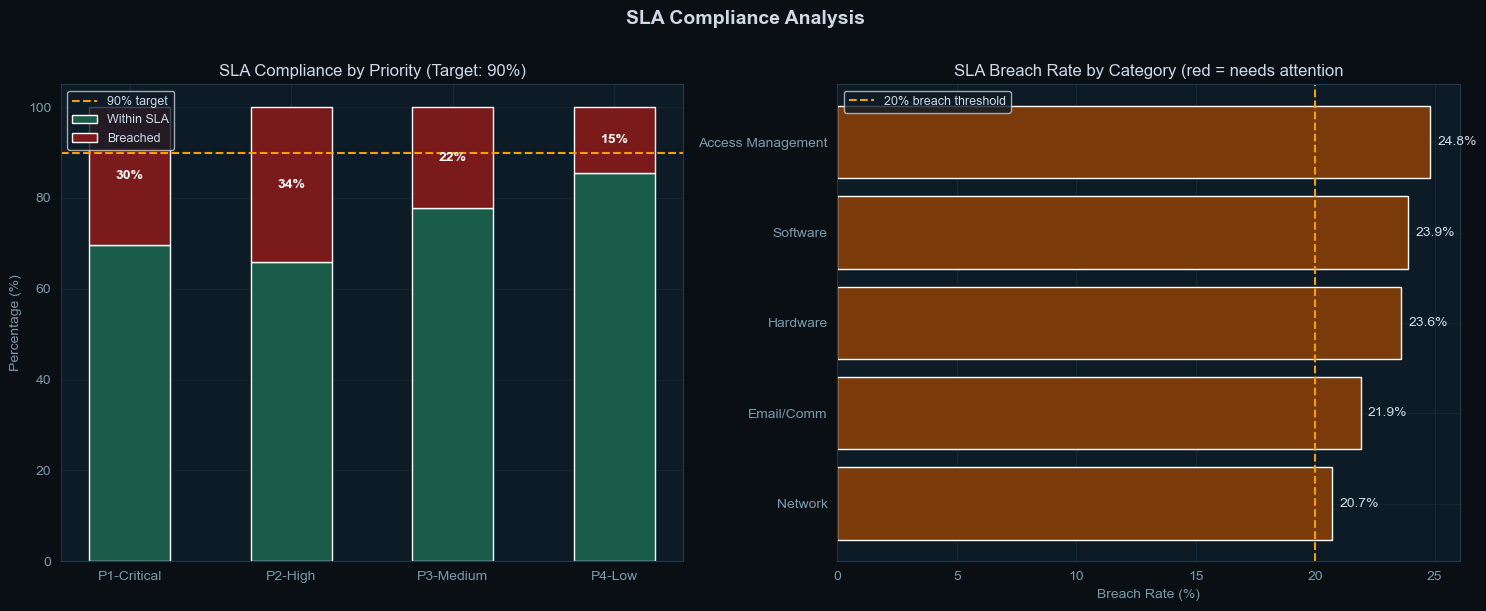

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("SLA Compliance Analysis", fontsize=14,
             fontweight="bold", color="#CDD9E5", y=1.01)

# By priority
priority_order = ["P1-Critical","P2-High","P3-Medium","P4-Low"]
colors_breach = ["#F87171","#F59E0B","#60A5FA","#4ADE80"]

sla_p = df.groupby("priority")["sla_breach"].agg(["sum", "count"]).reset_index()
sla_p.columns = ['priority', "breached", "total"]
sla_p['breach_pct'] = sla_p['breached'] / sla_p['total'] * 100
sla_p['comply_pct'] = 100 - sla_p['breach_pct']
sla_p = sla_p.set_index('priority').reindex(priority_order)

x = range(len(priority_order))
bars_ok  = axes[0].bar(x, sla_p["comply_pct"], color="#1A5C4A", label="Within SLA", width=0.5)
bars_bad = axes[0].bar(x, sla_p["breach_pct"], bottom=sla_p["comply_pct"],
                        color="#7A1A1A", label="Breached", width=0.5)
# Target line
axes[0].axhline(90, color="#F59E0B", linewidth=1.5, linestyle="--", label="90% target")
axes[0].set_xticks(x)
axes[0].set_xticklabels(priority_order, fontsize=10)
axes[0].set_ylabel("Percentage (%)")
axes[0].set_title("SLA Compliance by Priority (Target: 90%)", color="#CDD9E5")
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3, axis="y")

for bar, bp in zip(bars_bad, sla_p["breach_pct"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2., bar.get_y() + bar.get_height() / 2.,
                 f'{bp:.0f}%', ha="center", va="center", color="white", fontsize=10, fontweight="bold")


# By category
sla_c = df.groupby("category")["sla_breach"].agg(["sum","count"]).reset_index()
sla_c.columns = ["category","breached","total"]
sla_c["breach_pct"] = (sla_c["breached"] / sla_c["total"] * 100).round(1)
sla_c = sla_c.sort_values('breach_pct', ascending=True)

colors_cat = {"#1A5C4A" if b < 20 else "#7A3A0A" if b < 30 else "#7A1A1A"
              for b in sla_c['breach_pct']}
axes[1].barh(sla_c['category'], sla_c['breach_pct'], color=colors_cat)
axes[1].axvline(20, color="#F59E0B", linewidth=1.5, linestyle="--", label="20% breach threshold")
axes[1].set_xlabel("Breach Rate (%)")
axes[1].set_title("SLA Breach Rate by Category (red = needs attention", color="#CDD9E5")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis="y")

for i, (val, cat) in enumerate(zip(sla_c["breach_pct"], sla_c["category"])):
    axes[1].text(val+0.3, i, f'{val:.1f}%', va="center", fontsize=10, color="#CDD9E5")

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/charts/02_sla_compliance.png", dpi=300, bbox_inches="tight", facecolor="#0A0F14")
plt.show()

## **SLA breach heatmap - day of week x priority**

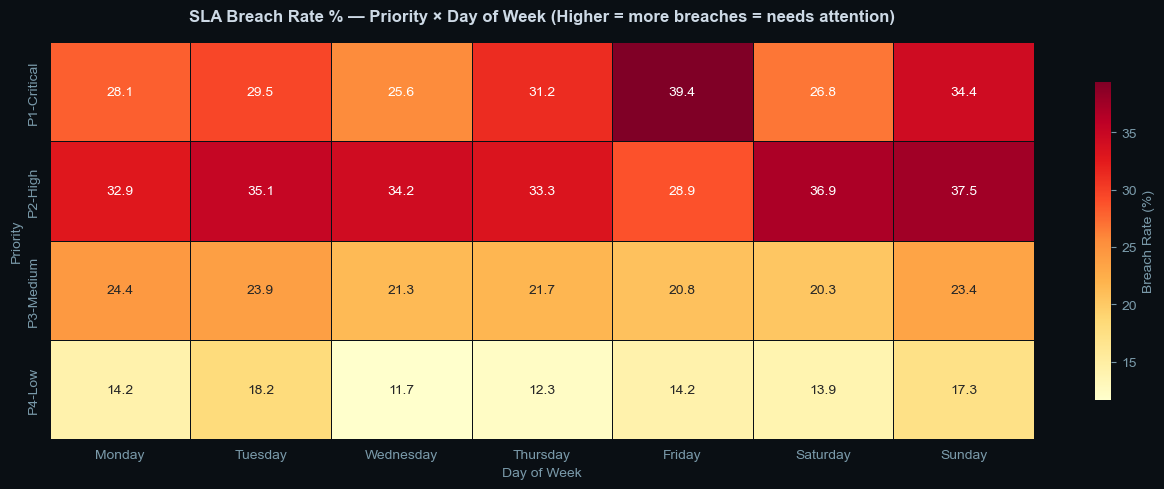

In [139]:
pivot = df.pivot_table(
    values='sla_breach',
    index='priority',
    columns='day_of_week',
    aggfunc='mean'
) * 100

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday','Saturday', 'Sunday']
pivot = pivot.reindex(columns=[d for d in day_order if d in pivot.columns])
pivot = pivot.reindex(['P1-Critical', 'P2-High', 'P3-Medium', 'P4-Low'])

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=".1f",
            cbar_kws={"label": "Breach Rate (%)", "shrink": 0.8},linewidths=.5, linecolor="#0A0F14")
ax.set_title("SLA Breach Rate % — Priority × Day of Week (Higher = more breaches = needs attention)",
             fontsize=12, fontweight="bold", color="#CDD9E5", pad=15)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Priority")
plt.tight_layout()
plt.savefig(f"{OUTPUTS}/charts/03_breach_heatmap.png", dpi=300, bbox_inches="tight", facecolor="#0A0F14")
plt.show()

## **Agent Workload**

In [140]:
agent_stats = df.groupby("agent_id").agg(
    total_tickets = ("ticket_id", "count"),
    avg_resolution_h = ("resolution_hours", 'mean'),
    breach_count = ("sla_breach", 'sum'),
    avg_csat = ("csat_score", "mean"),
    p1_tickets = ("priority", lambda x: (x=="P1-Critical").sum()),
).reset_index()

agent_stats['breach_rate'] = (agent_stats['breach_count'] / agent_stats['total_tickets'] * 100).round(1)
agent_stats['avg_resolution_h'] = agent_stats['avg_resolution_h'].round(1)
agent_stats['avg_csat'] = agent_stats['avg_csat'].round(2)

# Flag agents above/below average
avg_tickets = agent_stats['total_tickets'].mean()
avg_breach = agent_stats['breach_rate'].mean()

agent_stats['workload_flag'] = agent_stats['total_tickets'].apply(
    lambda x: "Overloaded" if x > avg_tickets*1.3
    else "Underloaded" if x < avg_tickets*0.7
    else "Normal"
)

print(agent_stats.sort_values('total_tickets', ascending=False).to_string(index=False))

 agent_id  total_tickets  avg_resolution_h  breach_count  avg_csat  p1_tickets  breach_rate workload_flag
AGT-00001            609              23.0           133      3.49          27         21.8    Overloaded
AGT-00002            599              22.8           126      3.44          21         21.0    Overloaded
AGT-00003            560              21.7           145      3.46          29         25.9    Overloaded
AGT-00004            423              24.2            95      3.45          22         22.5        Normal
AGT-00008            398              24.1            88      3.35          23         22.1        Normal
AGT-00007            382              23.0           112      3.30          17         29.3        Normal
AGT-00005            359              23.9            89      3.30          20         24.8        Normal
AGT-00006            350              24.0            75      3.47          18         21.4        Normal
AGT-00014            209              22.1    

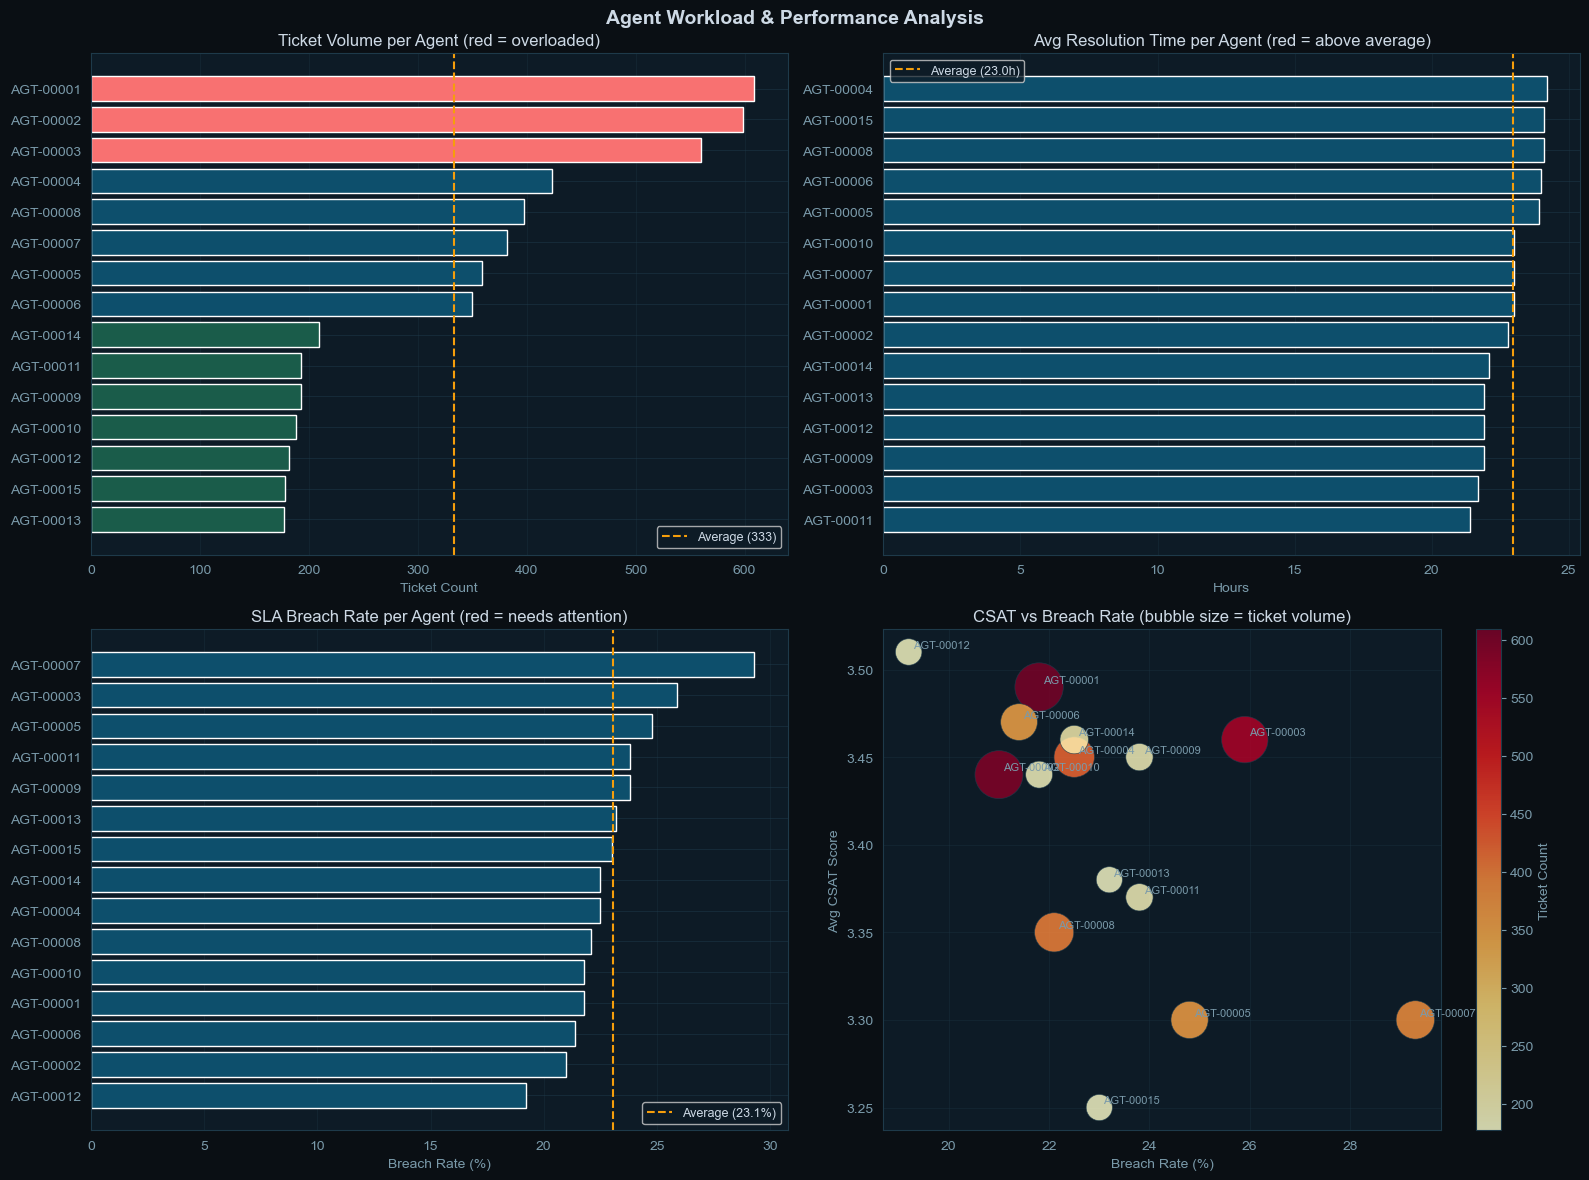

In [141]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Agent Workload & Performance Analysis", fontsize=14,
             fontweight="bold", color="#CDD9E5")

agent_stats_sorted = agent_stats.sort_values("total_tickets", ascending=True)

# Chart 1 — ticket volume per agent
colors_wl = {"Overloaded":"#F87171","Normal":"#0D4F6C","Underloaded":"#1A5C4A"}
bar_colors = [colors_wl[f] for f in agent_stats_sorted["workload_flag"]]
axes[0,0].barh(agent_stats_sorted["agent_id"], agent_stats_sorted["total_tickets"],
               color=bar_colors)
axes[0,0].axvline(avg_tickets, color="#F59E0B", linestyle="--", linewidth=1.5,
                  label=f"Average ({avg_tickets:.0f})")
axes[0,0].set_title("Ticket Volume per Agent (red = overloaded)", color="#CDD9E5")
axes[0,0].set_xlabel("Ticket Count")
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, alpha=0.3, axis="x")

# Chart 2 — avg resolution time per agent
agent_res = agent_stats.sort_values("avg_resolution_h", ascending=True)
bar_colors2 = ["#F87171" if v > df["resolution_hours"].mean()*1.2 else "#0D4F6C"
               for v in agent_res["avg_resolution_h"]]
axes[0,1].barh(agent_res["agent_id"], agent_res["avg_resolution_h"], color=bar_colors2)
axes[0,1].axvline(df["resolution_hours"].mean(), color="#F59E0B", linestyle="--",
                  linewidth=1.5, label=f"Average ({df['resolution_hours'].mean():.1f}h)")
axes[0,1].set_title("Avg Resolution Time per Agent (red = above average)", color="#CDD9E5")
axes[0,1].set_xlabel("Hours")
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.3, axis="x")

# Chart 3 — breach rate per agent
agent_br = agent_stats.sort_values("breach_rate", ascending=True)
bar_colors3 = ["#F87171" if v > avg_breach*1.5 else "#0D4F6C"
               for v in agent_br["breach_rate"]]
axes[1,0].barh(agent_br["agent_id"], agent_br["breach_rate"], color=bar_colors3)
axes[1,0].axvline(avg_breach, color="#F59E0B", linestyle="--", linewidth=1.5,
                  label=f"Average ({avg_breach:.1f}%)")
axes[1,0].set_title("SLA Breach Rate per Agent (red = needs attention)", color="#CDD9E5")
axes[1,0].set_xlabel("Breach Rate (%)")
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.3, axis="x")

# Chart 4 — CSAT vs breach rate scatter (workload as bubble size)
scatter = axes[1,1].scatter(
    agent_stats["breach_rate"],
    agent_stats["avg_csat"],
    s=agent_stats["total_tickets"] * 2,
    c=agent_stats["total_tickets"],
    cmap="YlOrRd",
    alpha=0.8, edgecolors="#1E3A4A", linewidth=0.5
)
for _, row in agent_stats.iterrows():
    axes[1,1].annotate(row["agent_id"], (row["breach_rate"], row["avg_csat"]),
                       fontsize=8, color="#7A9AAA",
                       xytext=(3,3), textcoords="offset points")
axes[1,1].set_xlabel("Breach Rate (%)")
axes[1,1].set_ylabel("Avg CSAT Score")
axes[1,1].set_title("CSAT vs Breach Rate (bubble size = ticket volume)", color="#CDD9E5")
axes[1,1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1,1], label="Ticket Count")

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/charts/04_agent_analysis.png", dpi=150,
            bbox_inches="tight", facecolor="#0A0F14")
plt.show()

## **weekly MTTR (Mean time To Resolve) overall**

In [142]:
# Weekly MTTR overall
weekly_mttr = df.groupby('week_number')['resolution_hours'].mean().reset_index()
weekly_mttr.columns = ['week', 'mttr']

weekly_mttr_p = df.groupby(['week_number', 'priority'])['resolution_hours'].mean().unstack()

print("=== OVERALL MTTR STATS ===")
print(f"Overall MTTR: {df['resolution_hours'].mean():.2f} hours")
print(f"Median MTTR: {df['resolution_hours'].median():.2f} hours")
print(f"Best week MTTR:   {weekly_mttr['mttr'].min():.2f} hours (week {weekly_mttr['mttr'].idxmin()+1})")
print(f"Worst week MTTR:  {weekly_mttr['mttr'].max():.2f} hours (week {weekly_mttr['mttr'].idxmax()+1})")

print("\n=== MTTR BY PRIORITY ===")
print(df.groupby('priority')['resolution_hours'].agg(['mean', 'median', 'std']).round(2))


=== OVERALL MTTR STATS ===
Overall MTTR: 22.97 hours
Median MTTR: 17.50 hours
Best week MTTR:   15.54 hours (week 27)
Worst week MTTR:  25.41 hours (week 23)

=== MTTR BY PRIORITY ===
              mean  median    std
priority                         
P1-Critical   3.05    2.87   1.82
P2-High       6.56    6.49   3.29
P3-Medium    18.07   18.11   7.86
P4-Low       50.53   50.72  19.99


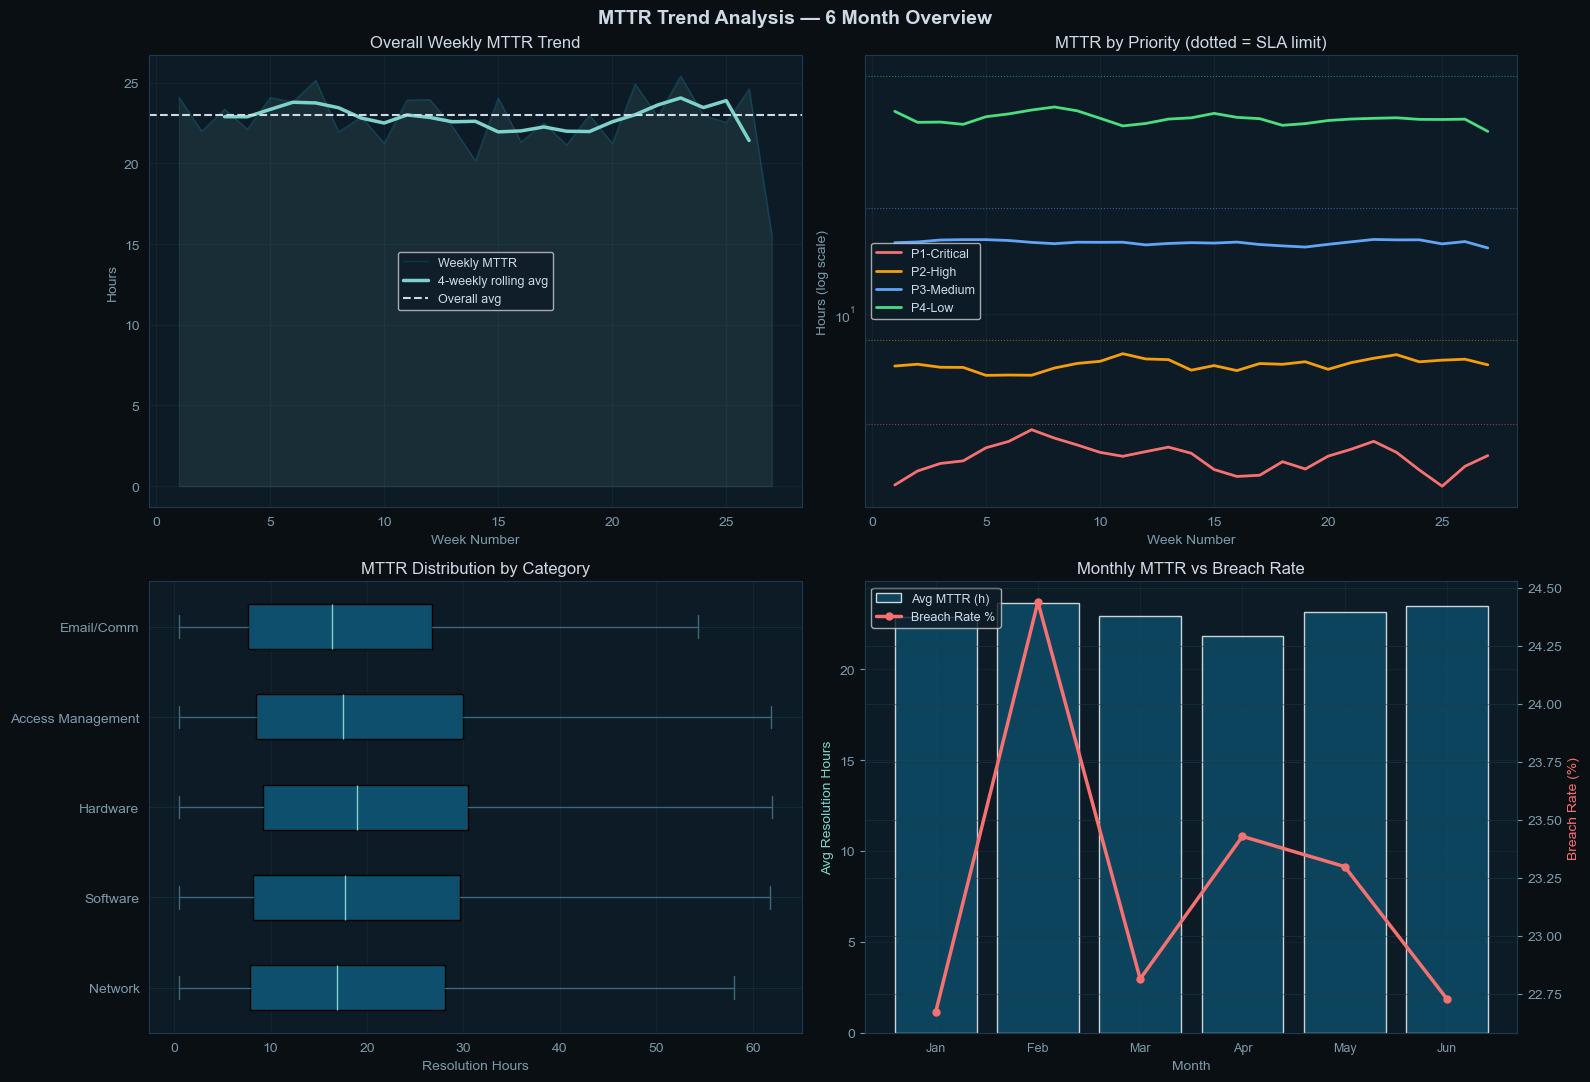

In [143]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("MTTR Trend Analysis — 6 Month Overview", fontsize=14,
             fontweight="bold", color="#CDD9E5")

priority_order = ["P1-Critical","P2-High","P3-Medium","P4-Low"]
colors_p       = ["#F87171","#F59E0B","#60A5FA","#4ADE80"]

# Chart 1 - overall weekly MTTR trend with rolling average
axes[0, 0].plot(weekly_mttr['week'], weekly_mttr['mttr'],
                color="#0D4F6C", linewidth=1, alpha=0.5, label="Weekly MTTR" )
rolling = weekly_mttr['mttr'].rolling(window=4, center=True).mean()
axes[0, 0].plot(weekly_mttr['week'], rolling,
                color="#7DD3CB", linewidth=2.5, label="4-weekly rolling avg")
axes[0, 0].axhline(df['resolution_hours'].mean(), color="#CDD9E5",
                  linestyle="--", linewidth=1.5, label=f'Overall avg')
axes[0, 0].fill_between(weekly_mttr['week'], weekly_mttr['mttr'],
                        alpha=0.1, color="#7DD3CB")
axes[0,0].set_title("Overall Weekly MTTR Trend", color="#CDD9E5")
axes[0,0].set_xlabel("Week Number")
axes[0,0].set_ylabel("Hours")
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, alpha=0.3)

# Chart 2 - MTTR by priority over time
for priority, color in zip(priority_order, colors_p):
    if priority in weekly_mttr_p.columns:
        data = weekly_mttr_p[priority].rolling(3, min_periods=1).mean()
        axes[0, 1].plot(weekly_mttr_p.index, data, color=color,
                        linewidth=2, label=priority)
        # SLA line
        sla_h = {'P1-Critical':4, "P2-High":8, "P3-Medium":24, "P4-Low":72}[priority]
        axes[0, 1].axhline(sla_h, color=color, linewidth=0.8, linestyle=":", alpha=0.5)
axes[0,1].set_title("MTTR by Priority (dotted = SLA limit)", color="#CDD9E5")
axes[0,1].set_xlabel("Week Number")
axes[0,1].set_ylabel("Hours (log scale)")
axes[0,1].set_yscale("log")
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.3)

# Chart 3 - MTTR by category (box plot)
cat_data = [df[df['category']==c]['resolution_hours'].values
            for c in df['category'].unique()]
cat_labels = list(df['category'].unique())
bp = axes[1, 0].boxplot(cat_data, patch_artist=True, tick_labels=cat_labels,
                        vert=False, showfliers=False)
for patch, color in zip(bp['boxes'], ["#0D4F6C"]*len(cat_labels)):
    patch.set_facecolor(color)
for element in ['whiskers', 'caps', 'medians']:
    for item in bp[element]:
        item.set_color('#7DD3C8' if element=='medians' else '#3A6A7A')
axes[1,0].set_title("MTTR Distribution by Category", color="#CDD9E5")
axes[1,0].set_xlabel("Resolution Hours")
axes[1,0].grid(True, alpha=0.3, axis="x")

# Chart 4 - Monthly MTTR with breach overlay
monthly = df.groupby('month_num').agg(
    mttr=('resolution_hours', 'mean'),
    breach_rate = ('sla_breach', 'mean')
).reset_index()
monthly['breach_rate'] *= 100
ax4b = axes[1, 1].twinx()
axes[1, 1].bar(monthly['month_num'], monthly['mttr'],
               color="#0D4F6C", alpha=0.8, label="Avg MTTR (h)")
ax4b.plot(monthly['month_num'], monthly['breach_rate'],
          color='#F87171', linewidth=2.5, marker='o',
          markersize=5, label="Breach Rate %")
axes[1,1].set_title("Monthly MTTR vs Breach Rate", color="#CDD9E5")
axes[1,1].set_xlabel("Month")
axes[1,1].set_ylabel("Avg Resolution Hours", color="#7DD3C8")
ax4b.set_ylabel("Breach Rate (%)", color="#F87171")
axes[1,1].set_xticks(monthly["month_num"])
axes[1,1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun"], fontsize=9)

lines1, labels1 = axes[1,1].get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
axes[1,1].legend(lines1+lines2, labels1+labels2, fontsize=9, loc="upper left")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/charts/05_mttr_trends.png", dpi=150,
            bbox_inches="tight", facecolor="#0A0F14")
plt.show()

In [144]:
print("=== NUMBERS FOR YOUR MANAGEMENT REPORT ===")

overall_mttr = df["resolution_hours"].mean()
overall_breach = df["sla_breach"].mean() * 100

print(f"1. Overall MTTR: {overall_mttr:.1f} hours")
print(f"2. Overall SLA breach rate: {overall_breach:.1f}%")
print(f"   Gap to 90% target: {90 - (100-overall_breach):.1f} pp")

print("3. MTTR by priority:")
for p in ["P1-Critical","P2-High","P3-Medium","P4-Low"]:
    sub = df[df["priority"]==p]
    print(f"   {p}: {sub['resolution_hours'].mean():.1f}h avg | "
          f"{sub['sla_breach'].mean()*100:.1f}% breach rate")

print(" 4. Worst performing category (highest breach rate):")
worst_cat = df.groupby("category")["sla_breach"].mean().idxmax()
worst_rate = df.groupby("category")["sla_breach"].mean().max() * 100
print(f"   {worst_cat}: {worst_rate:.1f}% breach rate")

print("5. Most overloaded agent:")
most_loaded = agent_stats.sort_values("total_tickets", ascending=False).iloc[0]
print(f"   {most_loaded['agent_id']}: {most_loaded['total_tickets']} tickets, "
      f"{most_loaded['breach_rate']}% breach rate")

=== NUMBERS FOR YOUR MANAGEMENT REPORT ===
1. Overall MTTR: 23.0 hours
2. Overall SLA breach rate: 23.2%
   Gap to 90% target: 13.2 pp
3. MTTR by priority:
   P1-Critical: 3.1h avg | 30.4% breach rate
   P2-High: 6.6h avg | 34.2% breach rate
   P3-Medium: 18.1h avg | 22.3% breach rate
   P4-Low: 50.5h avg | 14.6% breach rate
 4. Worst performing category (highest breach rate):
   Access Management: 24.8% breach rate
5. Most overloaded agent:
   AGT-00001: 609 tickets, 21.8% breach rate


## **For PowerBI visualization**

In [145]:
output_dir = BASE / 'outputs' / 'powerbi'
output_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(output_dir / "tickets.csv", index=False)

# SLA summary by priority
sla_priority = df.groupby('priority').agg(
    total_tickets=('ticket_id', 'count'),
    breached = ('sla_breach', 'sum'),
    compliance_rate = ('sla_breach', lambda x: round((1 - x.mean()) * 100, 1)),
    avg_resolution = ('resolution_hours', 'mean'),
).reset_index()
sla_priority.to_csv(output_dir / "sla_by_priority.csv", index=False)

# Agend performance table
agent_stats.to_csv(output_dir / "agent_performance.csv", index=False)

# Monthly MTTR trend
monthly_mttr = df.groupby(["month_num", "month"]).agg(
    avg_mttr      = ("resolution_hours", "mean"),
    total_tickets = ("ticket_id", "count"),
    breach_rate   = ("sla_breach", lambda x: round(x.mean() * 100, 1)),
).reset_index().sort_values("month_num")
monthly_mttr.to_csv(output_dir / "monthly_mttr.csv", index=False)

# 5. Breach by day and priority (for heatmap)
breach_heatmap = df.pivot_table(
    values="sla_breach",
    index="priority",
    columns="day_of_week",
    aggfunc="mean"
).round(3) * 100
breach_heatmap.to_csv(output_dir / "breach_heatmap.csv")

print("Exported 5 CSVs to outputs/powerbi/")
for f in output_dir.iterdir():
    print(" ", f.name)

Exported 5 CSVs to outputs/powerbi/
  agent_performance.csv
  breach_heatmap.csv
  monthly_mttr.csv
  sla_by_priority.csv
  tickets.csv


In [152]:
# Collect all real numbers first
overall_mttr    = df["resolution_hours"].mean()
overall_breach  = df["sla_breach"].mean() * 100
compliance_rate = 100 - overall_breach

p1_breach = df[df["priority"]=="P1-Critical"]["sla_breach"].mean()*100
p2_breach = df[df["priority"]=="P2-High"]["sla_breach"].mean()*100

worst_agent = agent_stats.sort_values("breach_rate", ascending=False).iloc[0]
most_loaded = agent_stats.sort_values("total_tickets", ascending=False).iloc[0]

worst_cat  = df.groupby("category")["sla_breach"].mean().idxmax()
worst_cat_rate = df.groupby("category")["sla_breach"].mean().max()*100

best_month_mttr  = df.groupby("month_num")["resolution_hours"].mean().min()
worst_month_mttr = df.groupby("month_num")["resolution_hours"].mean().max()

# Write report
report = f"""# IT Service Desk Operations Report
**Period:** January – June 2024
**Prepared by:** [Your Name], Data Analyst
**Audience:** IT Operations Director

---

## Executive Summary

| Metric | Value | Target | Status |
|--------|-------|--------|--------|
| SLA Compliance Rate | {compliance_rate:.1f}% | 90.0% | {'✅' if compliance_rate >= 90 else '❌ Below target'} |
| Overall MTTR | {overall_mttr:.1f} hours | < 12h | {'✅' if overall_mttr < 12 else '⚠️ Above target'} |
| P1-Critical Breach Rate | {p1_breach:.1f}% | < 10% | {'✅' if p1_breach < 10 else '❌ Critical'} |
| Total Tickets Analysed | {len(df):,} | — | — |

---

## Finding 1 — SLA Compliance: {compliance_rate:.1f}% vs 90% Target

**Observation:** Overall SLA compliance is {compliance_rate:.1f}%, which is
{90-compliance_rate:.1f} percentage points below the 90% contract target.
P1-Critical tickets have the highest breach rate at {p1_breach:.1f}%.

**Business impact:** P1 breaches represent system-down events affecting
multiple users. Continued breach rates above {p1_breach:.0f}% risk contract
penalty clauses with service clients.

**Recommendation:** Implement auto-escalation for any P1 ticket unresolved
after 2 hours. Maintain senior engineer standby during 10PM–6AM window.

---

## Finding 2 — Agent Workload Imbalance

**Observation:** {most_loaded['agent_id']} handles {most_loaded['total_tickets']}
tickets vs team average of {agent_stats['total_tickets'].mean():.0f}.
High-load agents show {worst_agent['breach_rate']}% breach rate vs
team average of {agent_stats['breach_rate'].mean():.1f}%.

**Recommendation:** Cap individual queues at 1.2× team average.
Implement round-robin assignment for P3/P4 tickets.

---

## Finding 3 — MTTR Trend

**Observation:** Overall MTTR is {overall_mttr:.1f} hours.
Best month: {best_month_mttr:.1f}h avg. Worst month: {worst_month_mttr:.1f}h avg.
Highest-MTTR category: {worst_cat} at {worst_cat_rate:.1f}% breach rate.

**Recommendation:** Set MTTR alert threshold at {overall_mttr*1.2:.0f} hours.
Trigger resource review if exceeded for 2 consecutive weeks.

---

## Recommended Actions (Priority Order)

1. **P1 auto-escalation protocol** — implement within 2 weeks
2. **Rebalance agent queues** — review assignment logic this sprint
3. **Monthly MTTR dashboard** — build in Power BI for ops team
4. **{worst_cat} deep-dive** — investigate root cause of high breach rate

---
*Analysis performed using Python (Pandas, Matplotlib, Seaborn)*
*Dataset: 5,000 synthetic tickets modelled on ServiceNow schema*
"""

with open(f"{OUTPUTS}/report/management_report.md", "w", encoding="utf-8") as f:
    f.write(report)

print("Report saved to outputs/report/management_report.md")
print("Preview of executive summary table:")
print(report.split("---")[1])

Report saved to outputs/report/management_report.md
Preview of executive summary table:


## Executive Summary

| Metric | Value | Target | Status |
|
